Scikit Learn or sklearn
. library for machine learning in python 
. built on numpy and matplotlib
. methods to evaluate your machine learning models
. very well designed API (programming library) 
. has in built machine learning models


What are we going to cover ? End to End Scikit Learn workflow
. Get data ready 
. Pick a model
. Fit the model and make prediction
. Evaluate the model
. improve with experimentation
. Save and reload your trained model
. putting it all together

In [1]:
#pip install matplotlib

In [2]:
#pip install sklearn

In [3]:

# Standard library imports 

import matplotlib.pyplot as pls
import pandas as pd
import numpy as np

In [4]:
#1. getting the data ready 
heart_disease = pd.read_csv('heart-disease.csv')
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# Creating X also known as features Matrix
X = heart_disease.drop('target',axis=1)

# creating Y also known as label matrix 
Y = heart_disease['target']


In [6]:
# Choos the right model and hyper parameters

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

# We will keep the default hyperparameters 
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [7]:
# Fit the model to the training data 
from sklearn.model_selection import train_test_split

# splitting X and Y into test and train sets 
X_train,X_test,y_train,y_test = train_test_split(X,Y, test_size= 0.2)

In [8]:
# fitting the model to training data
clf.fit(X_train,y_train)

RandomForestClassifier()

In [9]:
# Prediction using the trained model

y_preds = clf.predict(X_test)
y_preds


array([1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0])

In [10]:
# evaluate the model on the training data and test data 
clf.score(X_train,y_train)

1.0

In [11]:
clf.score(X_test,y_test)

0.819672131147541

In [12]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print(classification_report(y_test,y_preds))


              precision    recall  f1-score   support

           0       0.83      0.80      0.81        30
           1       0.81      0.84      0.83        31

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [13]:
confusion_matrix(y_test,y_preds)

array([[24,  6],
       [ 5, 26]])

In [14]:
accuracy_score(y_test,y_preds)

0.819672131147541

In [15]:
# improve the model 
# try different types of hyper parameters 

np.random.seed(42)
for i in range(10,110,10):
    print(f"Trying model with {i} estimators")
    clf = RandomForestClassifier(n_estimators=i).fit(X_train,y_train)
    print(f"Model accuracy on test set: {clf.score(X_test,y_test)* 100:2f}")
    print('')


Trying model with 10 estimators
Model accuracy on test set: 78.688525

Trying model with 20 estimators
Model accuracy on test set: 81.967213

Trying model with 30 estimators
Model accuracy on test set: 78.688525

Trying model with 40 estimators
Model accuracy on test set: 80.327869

Trying model with 50 estimators
Model accuracy on test set: 81.967213

Trying model with 60 estimators
Model accuracy on test set: 78.688525

Trying model with 70 estimators
Model accuracy on test set: 81.967213

Trying model with 80 estimators
Model accuracy on test set: 83.606557

Trying model with 90 estimators
Model accuracy on test set: 80.327869

Trying model with 100 estimators
Model accuracy on test set: 80.327869



In [16]:
# Save a model and load 
import pickle

pickle.dump(clf,open('randomforestmodel1.pkl','wb'),)

In [17]:
# load model
loaded_model = pickle.load(open('randomforestmodel1.pkl','rb'))
loaded_model.score(X_test,y_test)

0.8032786885245902

Getting the data ready 
Three main things we have to do:
 . split the data into features and labels ( ussually X and y)
 . Filling (also called imputing) or disregarding missing values 
 . Converting non numerical values to numerical values also called feature encoding 
 


In [18]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [19]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [20]:
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [21]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [22]:
X.shape,Y.shape

((303, 13), (303,))

In [23]:
# Clean, Transform and Reduce
# make sure its all numerical 
 
car_sales = pd.read_csv('car-sales-extended.csv')
car_sales.head()



,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [24]:
len(car_sales)

1000

In [25]:
cols =car_sales.dtypes
cols


Make             object
Colour           object
Odometer (KM)     int64
Doors             int64
Price             int64
dtype: object

In [26]:
X = car_sales.drop('Price',axis=1)
Y = car_sales['Price']

In [27]:
X

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431,4
1,BMW,Blue,192714,5
2,Honda,White,84714,4
3,Toyota,White,154365,4
4,Nissan,Blue,181577,3
...,...,...,...,...
995,Toyota,Black,35820,4
996,Nissan,White,155144,3
997,Nissan,Blue,66604,4
998,Honda,White,215883,4


In [28]:
Y

0      15323
1      19943
2      28343
3      13434
4      14043
       ...  
995    32042
996     5716
997    31570
998     4001
999    12732
Name: Price, Length: 1000, dtype: int64

In [29]:
# importing regression model from sklearn
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()

In [30]:
# turn the categories into numbers so that model can understand it
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['Make','Colour','Doors']
onehot = OneHotEncoder()
transformer = ColumnTransformer([('onehot',onehot,categorical_features)], remainder='passthrough')

transformed_X = transformer.fit_transform(X)

In [31]:
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]])

In [32]:
pd.DataFrame(transformed_X)
# you can see that the 12th column which is the odomenter hasn't chnaged at all 
# one hot encoding changes categories to numbers

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [33]:
# dummies function from pandas which does same thins as to one hot encoding
dummies = pd.get_dummies(car_sales[['Make','Colour','Doors']])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [34]:
#lets fit the model
np.random.seed(42)
X_train,X_test,y_train,y_test = train_test_split(transformed_X,Y, test_size=0.2)

model.fit(X_train,y_train)

RandomForestRegressor()

In [35]:
model.score(X_test,y_test)*100

32.35867221569877

What if there are missing values 

1. fill the value with some value, this is known as imputation
2. remove the samples with missing values altogether 

In [36]:
car_sales_missing = pd.read_csv('car-sales-extended-missing-data.csv')
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [37]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [38]:
# lets convert data to numbers
X = car_sales_missing.drop('Price',axis=1)
Y = car_sales_missing['Price']

In [39]:
X

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431.0,4.0
1,BMW,Blue,192714.0,5.0
2,Honda,White,84714.0,4.0
3,Toyota,White,154365.0,4.0
4,Nissan,Blue,181577.0,3.0
...,...,...,...,...
995,Toyota,Black,35820.0,4.0
996,NaN,White,155144.0,3.0
997,Nissan,Blue,66604.0,4.0
998,Honda,White,215883.0,4.0


In [40]:
Y

0      15323.0
1      19943.0
2      28343.0
3      13434.0
4      14043.0
        ...   
995    32042.0
996     5716.0
997    31570.0
998     4001.0
999    12732.0
Name: Price, Length: 1000, dtype: float64

In [41]:
#fill missing data with pandas 
car_sales_missing['Make'].fillna('Missing', inplace=True)

#filling the colour column 
car_sales_missing['Colour'].fillna('Missing',inplace = True)

# filling the odometer column with  mean 

car_sales_missing['Odometer (KM)'].fillna(car_sales_missing['Odometer (KM)'].mean(), inplace = True)


# filling the doors column 

car_sales_missing['Doors'].fillna(4,inplace = True)

car_sales_missing.isna().sum()

/var/folders/r2/g26jvc3x32jfw93vlbd3whh00000gn/T/ipykernel_1572/2498871704.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_sales_missing['Make'].fillna('Missing', inplace=True)
/var/folders/r2/g26jvc3x32jfw93vlbd3whh00000gn/T/ipykernel_1572/2498871704.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

In [42]:
# removing rows with missing price values
car_sales_missing.dropna(inplace=True)

In [43]:
car_sales_missing.isna().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [44]:
len(car_sales_missing)

950

In [45]:
# lets convert data to numbers
X = car_sales_missing.drop('Price',axis=1)
Y = car_sales_missing['Price']

In [46]:
# turn the categories into numbers so that model can understand it
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['Make','Colour','Doors']
onehot = OneHotEncoder()
transformer = ColumnTransformer([('onehot',onehot,categorical_features)], remainder='passthrough')

transformed_X = transformer.fit_transform(X)

In [47]:
transformed_X

<950x15 sparse matrix of type '<class 'numpy.float64'>'
	with 3800 stored elements in Compressed Sparse Row format>

In [48]:
# Fill missing values with Sci Kit learn 
car_sales_sci = pd.read_csv('car-sales-extended-missing-data.csv')
car_sales_sci

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [49]:
car_sales_sci.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [50]:
# dropping the rows with missing price which is the label column
car_sales_sci.dropna(subset=['Price'],inplace=True)
car_sales_sci.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [51]:
# splitting into X and y 
X = car_sales_sci.drop('Price',axis=1)
y = car_sales_sci['Price']

In [52]:
X.head()

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431.0,4.0
1,BMW,Blue,192714.0,5.0
2,Honda,White,84714.0,4.0
3,Toyota,White,154365.0,4.0
4,Nissan,Blue,181577.0,3.0


In [53]:
y.head()

0    15323.0
1    19943.0
2    28343.0
3    13434.0
4    14043.0
Name: Price, dtype: float64

In [54]:

# fill missing values using simple imputer 
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


#fill categorical values with missing and numerical values with mean 
cat_imputer = SimpleImputer(strategy = 'constant',fill_value='missing')
door_imputer = SimpleImputer(strategy='constant',fill_value=4)
num_imputer = SimpleImputer(strategy='mean')


#define Columns 
cat_cols = ['Make','Colour']
door =['Doors']
num_cols = ['Odometer (KM)']


# Create an imputer that fills missing values/data 
imputer = ColumnTransformer([
    ('cat_imputer',cat_imputer,cat_cols),
    ('Door_imputer',door_imputer,door),
    ('nume_imputer',num_imputer,num_cols)
])


imputer

ColumnTransformer(transformers=[('cat_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['Make', 'Colour']),
                                ('Door_imputer',
                                 SimpleImputer(fill_value=4,
                                               strategy='constant'),
                                 ['Doors']),
                                ('nume_imputer', SimpleImputer(),
                                 ['Odometer (KM)'])])

In [55]:
# transform data 
filled_X = imputer.fit_transform(X)

filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], dtype=object)

In [56]:
fdx = pd.DataFrame(filled_X,columns=['Make','Colour','Doors','Odometer (KM)'])
fdx.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [57]:
fdx.head()

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0


In [58]:
# turn the categories into numbers so that model can understand it
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['Make','Colour','Doors']
onehot = OneHotEncoder()
transformer = ColumnTransformer([('onehot',onehot,categorical_features)], remainder='passthrough')

transformed_X = transformer.fit_transform(fdx)


In [59]:
#now we fit the model

np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(transformed_X,y,test_size=0.2)

model = RandomForestRegressor()

model.fit(X_train,y_train)
model.score(X_test,y_test)*100

21.990196728583943

CHOOSING THE RIGHT ESTIMATOR/ALGORITHM FOR YOUR MODEL 

1. Sklearn refers to machine learning models, algorithms as estimators
2. Classificatio means predicting categories (heart disease or not) - clf is short for classifier 
3. Regression means predicting a number such as price of a car 
4. refer sklearn machine learning map



In [60]:
#picking a machine learning model for a regression problem
# get california housing dataset 

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [61]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [62]:
housing_df = pd.DataFrame(housing['data'],columns =housing['feature_names'])
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [63]:
housing_df['target']= housing['target']

In [64]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [65]:
#import algorithm/estimator
#set random seed 

np.random.seed(42)


#create data 
X = housing_df.drop('target',axis=1)
y= housing_df['target']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2)


In [66]:
#instantiate and fit the model
from sklearn.linear_model import Ridge

model = Ridge()
model.fit(X_train,y_train)
model.score(X_test,y_test)*100


57.585496114401245

In [67]:
#trying another models
# trying an ensemble model - its a combination of smaller moedels
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor()
model2.fit(X_train,y_train)
model2.score(X_test,y_test)*100

80.48502475905298

In [68]:
# Choosing an estimator for a classification problem 
heart_disease = pd.read_csv('heart-disease.csv')
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [69]:
len(heart_disease)

303

In [70]:
#trying linear svc means as the machine learning map says so
from sklearn.svm import LinearSVC

#setting the random seed
np.random.seed(42)

#getting the data ready 
X= heart_disease.drop('target',axis=1)
y=heart_disease['target']


#train test split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

#instantiate linear svc
clf = LinearSVC()
clf.fit(X_train,y_train)

#evaluate Linear SVC
clf.score(X_test,y_test)

0.8688524590163934

In [71]:
#trying Random forest classifier
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)


#not changing X and y 
clf2 = RandomForestClassifier(n_estimators=765)

clf2.fit(X_train,y_train)
clf2.score(X_test,y_test)


0.8688524590163934

if you have structered data use ensemble methods, if you have unstructed data use deeplearning or transfer learning methods

fit the model/algorithm on our data and use it make prediction

1. X-> feature variables, feature etc
2. y-> target, target data

fit function basically trains the model to find patterns in the training data, then during evaluation model uses the pattern it found during training to predict the outcome or the target

there are 2 ways to predict
1. predict()
2. predict_proba()

In [72]:
# Make predictions using machine learning models 
y_pred = clf.predict(X_test)

ypdf= pd.DataFrame(y_pred)
ypdf.head()
#predict_proba 
#y_pred_proba= clf.predict_proba(X_test)

,0
0,0
1,1
2,1
3,0
4,1


In [73]:
ytdf = pd.DataFrame(y_test)
ytdf.head()

,target
179,0
228,0
111,1
246,0
60,1


In [74]:
# Compare predictions to truth labels to evaluate model
np.mean(y_pred == y_test)

np.float64(0.8688524590163934)

In [75]:
clf.score(X_test,y_test)

0.8688524590163934

In [76]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8688524590163934

predict_proba() returns probabilities of a classification label

In [77]:
#make predictions with predict_proba()
clf2.predict_proba(X_test[:5])


array([[0.89411765, 0.10588235],
       [0.43267974, 0.56732026],
       [0.45751634, 0.54248366],
       [0.87843137, 0.12156863],
       [0.19869281, 0.80130719]])

In [78]:
clf2.predict(X_test[:5])

array([0, 1, 1, 0, 1])

In [79]:
heart_disease['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

Predict can also be used on Regression models

Evaluating a machine learning model 
 
 There are 3 in built ways to evaluate estimatiors in SciKit learn
 1. Estimators in built score method 
 2. the scoring parameter 
 3. Problem specific metric functions 
 

In [80]:
# Evaluarting a model with score method
clf2.score(X_test,y_test)*100

86.88524590163934

In [81]:
# The highest value for score method is 1.0, the lowest in 0.0
# training score > testing score

clf2.score(X_train,y_train)

1.0

In [82]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop('target',axis=1)
y = heart_disease['target']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

clf = RandomForestClassifier()

clf.fit(X_train,y_train)

RandomForestClassifier()

In [83]:
clf.score(X_test,y_test)

0.8524590163934426

In [84]:
# cross val score takes the classifier, X and y not the the test data like score function
cross_val_score(clf,X,y,cv=5)

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

In [85]:
np.random.seed(42)

#single training and test score 
clf_single_score = clf.score(X_test,y_test)

#take mean of 5 fold cross validation score 

clf_cross_val_score = np.mean(cross_val_score(clf,X,y,cv=5))

#compare the two

clf_single_score,clf_cross_val_score

#prefer the cross val  score over single score 


(0.8524590163934426, np.float64(0.8248087431693989))

In [86]:
# if the scoring parameter is set to None, cross val score uses the default scoring method of the classifier is used, which in this case is mean accuracy
cross_val_score(clf,X,y,cv=5,scoring= None)

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

  CLASSIFICATION MODEL EVALUATION METRICS 
  1. Accuracy 
  2. Area under ROC curve 
  3. Confusion Matrix 
  4. Classification report 


In [87]:
# Accuracy
crossvalscore=cross_val_score(clf,X,y,cv=5)
np.mean(crossvalscore)

np.float64(0.8149726775956283)

In [88]:
print(f'Heart Disease Classifier accuracy (Cross Validated Accuracy):{np.mean(crossvalscore)*100:2f}%')

Heart Disease Classifier accuracy (Cross Validated Accuracy):81.497268%


In [89]:
# Area under ROC curve
# ROC - Receiver Operating Charechteristic --> also called AUC
# area under curve or roc curve 

# comparison of a models true positive rate (TPR) v/s false positive rate (FPR)
# a true postive means a model predicts 1 when the truth is 1 
# a false positive is when a model predicts 1 when the truth is 0
# true negative is model predicts 0 when the truth is 0 
# false negative when model predicts 0 when the truth is 1 

from sklearn.metrics import roc_curve

# making predictions with probabilities 
y_prods = clf.predict_proba(X_test)

y_prods[:10]

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82],
       [0.14, 0.86],
       [0.36, 0.64],
       [0.95, 0.05],
       [0.99, 0.01],
       [0.47, 0.53]])

In [90]:
# taking only the probabibilities of the positives
y_prods_positive = y_prods[:,1]
y_prods_positive[:10]

array([0.11, 0.51, 0.57, 0.16, 0.82, 0.86, 0.64, 0.05, 0.01, 0.53])

In [91]:
# calculating fpr, tpr, thresholds

fpr,tpr,thresholds = roc_curve(y_test,y_prods_positive)

#check the fpr
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.03448276, 0.03448276, 0.03448276, 0.03448276, 0.06896552,
       0.06896552, 0.10344828, 0.13793103, 0.13793103, 0.17241379,
       0.17241379, 0.27586207, 0.4137931 , 0.48275862, 0.55172414,
       0.65517241, 0.72413793, 0.72413793, 0.82758621, 1.        ])

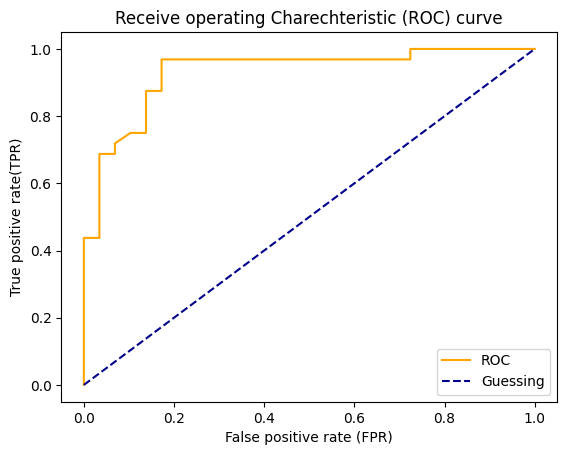

In [92]:
# create  a function for plotting ROC curve 
import matplotlib.pyplot as plt 

def plot_roc_curve(fpr,tpr):
    '''plots an ROC curve given the false positive rate(fpr)
     and true positive rate (tpr)'''
    
    #plot ROC curve
    plt.plot(fpr,tpr,color ='orange',label = 'ROC')

    #plot line with no predictive power
    plt.plot([0,1],[0,1],color ='darkblue',linestyle='--',label ='Guessing')

    # customize the plot
    plt.xlabel('False positive rate (FPR)')
    plt.ylabel('True positive rate(TPR)')
    plt.title('Receive operating Charechteristic (ROC) curve')
    plt.legend()
    plt.show()


plot_roc_curve(fpr,tpr)



In [93]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,y_prods_positive)

np.float64(0.9304956896551724)

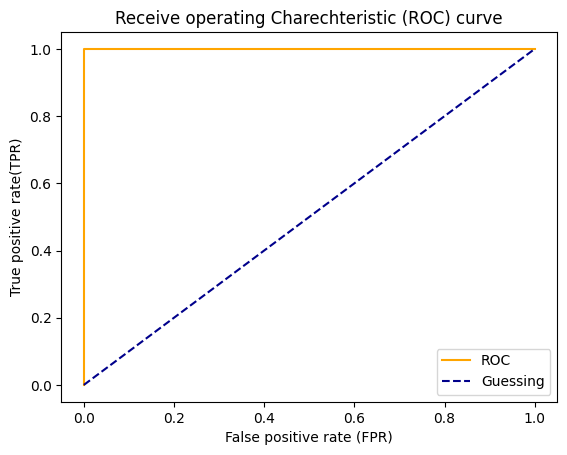

In [94]:
#plot perfect ROC curve and AUC score

fpr,tpr,thresholds = roc_curve(y_test,y_test)
plot_roc_curve(fpr,tpr)

In [95]:
#perfect AUC score
roc_auc_score(y_test,y_test)

np.float64(1.0)

In [96]:
# Confusion Matrix 
''' A consfusion matrix is a quick way to compare  the labels a model predicts versus the actual labels it was supposed to predict 
 In essence giving you an idea where the model getting confused'''
 
 
from sklearn.metrics import confusion_matrix


y_preds = clf.predict(X_test)

confusion_matrix(y_test,y_preds)

array([[24,  5],
       [ 4, 28]])

In [97]:
#visualize confusion metrics with pd.crosstab()

pd.crosstab(y_test,y_preds,rownames=['Actual labels'],colnames=['predicted labels'])

predicted labels,0,1
Actual labels,,
0,24,5
1,4,28


In [98]:
24+5+4+28

61

In [99]:
len(y_test)

61

In [100]:
#pip install seaborn

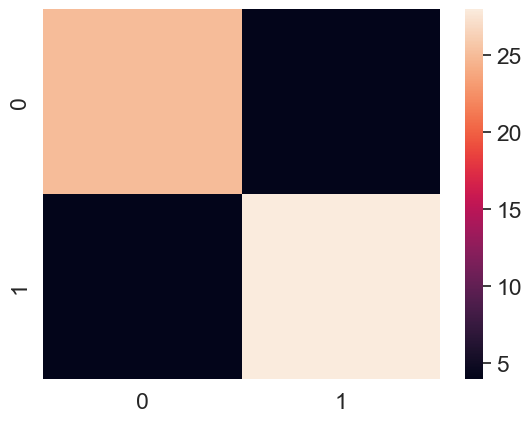

In [101]:
# make our confusion matrix more visual with seaborns heatmap

import seaborn as sns

#set the font scale
sns.set(font_scale= 1.5)

#create a confusion matrix 
conf_mat = confusion_matrix(y_test,y_pred)

# plot it using seaborn
sns.heatmap(conf_mat);
 


In [102]:
# creating a confusion matrix using scikit learn 
''' needs scikit learn version 1.0 or above '''
import sklearn
sklearn.__version__

'1.6.1'

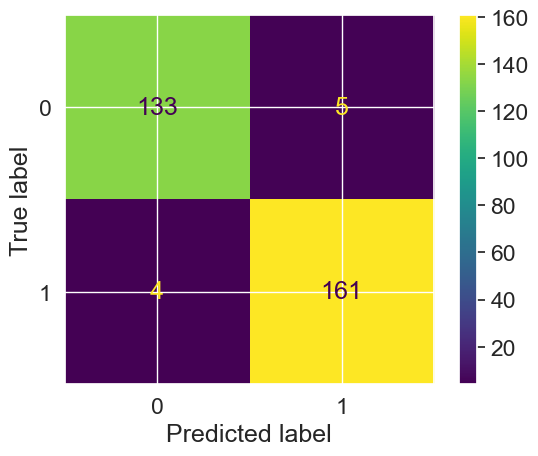

In [103]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(estimator=clf,X=X,y=y);

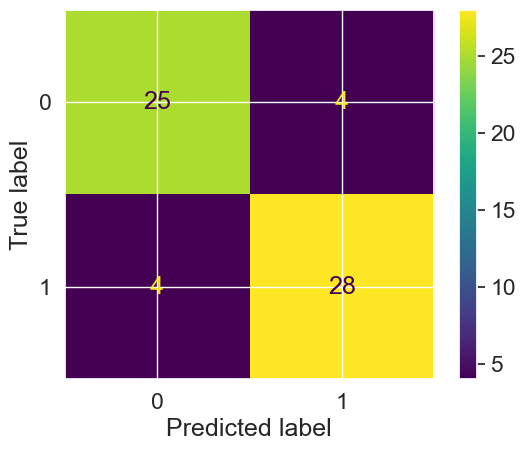

In [104]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred);

In [105]:
# Classification report 

from sklearn.metrics import classification_report

print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [106]:
''' where precision and recall become valuable'''


disease_true  = np.zeros(10000)
disease_true[0] = 1 # only one positive cases 


disease_preds = np.zeros(10000) # model predicts every case as zero

pd.DataFrame(classification_report(disease_true,disease_preds, output_dict=True))

/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000


REGRESSION MODEL EVALUATION METRICS
1. R**2 pronounced as r squared or coefficient of determination
2. Mean Absolute Error (MAE)
3. Mean Squared Error (MSE)

In [107]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)

X = housing_df.drop('target',axis=1)
y = housing_df['target']


X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2)

model =  RandomForestRegressor()

model.fit(X_train,y_train)

y_preds = model.predict(X_test)

In [108]:

model.score(X_test,y_test)

0.8059809073051385

In [109]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [110]:
# r2 score
'''R2 score comapares your model preditctions to the mean of the target. values can range between negative infinity( a very poor model)
 to 1 for a perfect model. if a model predicts the mean then r squared value will be 0 '''
from sklearn.metrics import r2_score

r2_score(y_true = y_test,y_pred = y_preds)

0.8059809073051385

In [111]:
''' Mean Absolute Error is the average of the absolute differences between preoictions and actual values. it gives you and idea of how wrong 
your model's predictions are'''

#MAE 
from sklearn.metrics import mean_absolute_error

y_preds = model.predict(X_test)
mae = mean_absolute_error(y_test,y_preds)
mae

0.3270458119670544

In [112]:
y_preds

array([0.49058  , 0.75989  , 4.9350165, ..., 4.8539888, 0.71491  ,
       1.66568  ])

In [113]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: target, Length: 4128, dtype: float64

In [114]:
df = pd.DataFrame( data= {'Actual values': y_test,
                        'predicted values':y_preds})
df['differences'] = df['predicted values'] - df['Actual values']

df.head()

,Actual values,predicted values,differences
20046,0.47700,0.490580,0.013580
3024,0.45800,0.759890,0.301890
15663,5.00001,4.935016,-0.064994
20484,2.18600,2.558640,0.372640
9814,2.78000,2.334610,-0.445390


In [115]:
df['differences'].mean()

np.float64(0.011913192441860052)

In [116]:
# mae using differences and formulas
np.abs(df['differences']).mean()

np.float64(0.3270458119670544)

In [117]:
''' Mean squared Error  is the mean of the square of errors between actual and predicted values. this amplifies outliers'''
#MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_preds)
mse



0.2542443610174998

In [118]:
df['squared differences'] = np.square(df['differences'])
df.head()

,Actual values,predicted values,differences,squared differences
20046,0.47700,0.490580,0.013580,0.000184
3024,0.45800,0.759890,0.301890,0.091138
15663,5.00001,4.935016,-0.064994,0.004224
20484,2.18600,2.558640,0.372640,0.138861
9814,2.78000,2.334610,-0.445390,0.198372


In [119]:
df['squared differences'].mean()

np.float64(0.2542443610174998)

### Improving a Machine Learning Model 

First predictions = baseline predictions

First model = Baseline model


From a data perspective, 

- could we collect more data?, generally the more the data the better

- Could we improve our data ?, 


From a model perspective,

1. is there a better model that we could use ?

2. Could we improve the current model ?



Hyperparameters v/s Parameters

Paremeters = model finds patterns in data 

Hyperparameters = settings on a model you can adjust to (potentially) improve its ability to find patterns

There are 3 ways to adjust hyperparameters

1. By hand

2. With Random search CV

3. Exhaustively with GridSearchCV




In [120]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()


In [121]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [122]:
# Tuning HyperParameters by Hand 
''' Lets make 3 sets, training, test and validation'''

''' we are going to adjust 
1. max_depth
2. max_features
3. min_samples_leaf
4. min_sample_split
5.n_estimators'''

from sklearn.metrics import precision_score, recall_score,f1_score

def evalutate_preds(y_true,y_preds):
    ''' function which performs evaluation comparison on y_true labels vs y_pred labels on a classification model'''
    accuracy = accuracy_score(y_true,y_preds)
    precision = precision_score(y_true,y_preds)
    recall = recall_score(y_true,y_preds)
    f1 = f1_score(y_true,y_preds)
    metric_dict ={'Accuracy':round(accuracy,2),
                  'precision': round(precision,2),
                  'recall':round(precision,2),
                  'f1':round(f1,2)}
    
    print(f"Acc:{accuracy*100:.2f}%")
    print(f"Precision:{precision:.2f}")
    print(f"recall:{recall:.2f}")
    print(f"f1 score : {f1:.2f}")

    return metric_dict




In [123]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [124]:
np.random.seed(42)

#shuffle the data 
heart_disease_shuffled = heart_disease.sample(frac=1)

# Split into X and y
X = heart_disease_shuffled.drop('target',axis=1)
y= heart_disease_shuffled['target']


# split the data into train, validation and test split
train_split = round(0.7*len(heart_disease_shuffled)) # 70% of data 
valid_split = round(train_split+ 0.15*len(heart_disease_shuffled)) # 15 percent of data 

X_train, y_train = X[:train_split],y[:train_split]
X_valid,y_valid = X[train_split:valid_split],y[train_split:valid_split]
X_test,y_test = X[valid_split:],y[valid_split]

len(X_train),len(X_valid),len(X_test)

clf = RandomForestClassifier()

clf.fit(X_train,y_train)


# make  baseline predictions
y_preds = clf.predict(X_valid)

# evaluate the classifier on validation set 
baseline_metrics = evalutate_preds(y_valid,y_preds)


Acc:82.22%
Precision:0.81
recall:0.88
f1 score : 0.85


In [125]:
clf2 = RandomForestClassifier(n_estimators= 300)
clf2.fit(X_train,y_train)


y_preds2 = clf2.predict(X_valid)

metrics2 = evalutate_preds(y_valid,y_preds2)

Acc:84.44%
Precision:0.85
recall:0.88
f1 score : 0.86


In [126]:
# Hyper parameter tuning with Randomized search cv

from sklearn.model_selection import RandomizedSearchCV

grid ={'n_estimators': [10,100,200],
       'max_depth':[None,5,10,20],
       'max_features': ['auto','sqrt'],
       'min_samples_split':[2,4,6],
       'min_samples_leaf':[1,2,4]}

np.random.seed(42)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size = 0.2)

clf = RandomForestClassifier(n_jobs =1 )

#Setup RandomizedSearchCV
rs_clf = RandomizedSearchCV(estimator=clf,
                            param_distributions=grid,
                            n_iter = 10, # number of models to try
                            verbose = 2)

In [127]:
rs_clf

RandomizedSearchCV(estimator=RandomForestClassifier(n_jobs=1),
                   param_distributions={'max_depth': [None, 5, 10, 20],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 4, 6],
                                        'n_estimators': [10, 100, 200]},
                   verbose=2)

In [128]:
#fit rs clf

rs_clf.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=4, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=4, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=4, min_samples_split=6, n_estimators=10; total tim

/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 436, in _validate_params
    validate_parame

RandomizedSearchCV(estimator=RandomForestClassifier(n_jobs=1),
                   param_distributions={'max_depth': [None, 5, 10, 20],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 4, 6],
                                        'n_estimators': [10, 100, 200]},
                   verbose=2)

In [129]:
rs_clf.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 10}

In [130]:
rs_y_preds = rs_clf.predict(X_test)

rs_metrics = evalutate_preds(y_test,rs_y_preds)

Acc:83.61%
Precision:0.76
recall:0.93
f1 score : 0.84


In [131]:
# Hyper parameter tuning with GridSearchCV

from sklearn.model_selection import GridSearchCV

grid2 = {'n_estimators': [200,500],
       'max_depth':[None],
       'max_features': ['auto','sqrt'],
       'min_samples_split':[6],
       'min_samples_leaf':[1,2]}

gs_clf = GridSearchCV(estimator = clf,
                      param_grid= grid2,
                      cv = 5, 
                      verbose = 2)

gs_clf.fit(X_train,y_train)
y_preds_gs = gs_clf.predict(X_test)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=500; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=500; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n

/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/Users/aravinds/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 436, in _validate_params
    validate_parame

In [132]:
gs_metrics = evalutate_preds(y_test,y_preds_gs)

Acc:83.61%
Precision:0.78
recall:0.89
f1 score : 0.83


In [133]:
gs_clf.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 6,
 'n_estimators': 200}

In [134]:
#comparing metrics

compare_metrics = pd.DataFrame({'Baseline':baseline_metrics,
                                'Clf2':metrics2,
                                'Random Search':rs_metrics,
                                'Grid Search': gs_metrics})

compare_metrics

,Baseline,Clf2,Random Search,Grid Search
Accuracy,0.82,0.84,0.84,0.84
precision,0.81,0.85,0.76,0.78
recall,0.81,0.85,0.76,0.78
f1,0.85,0.86,0.84,0.83


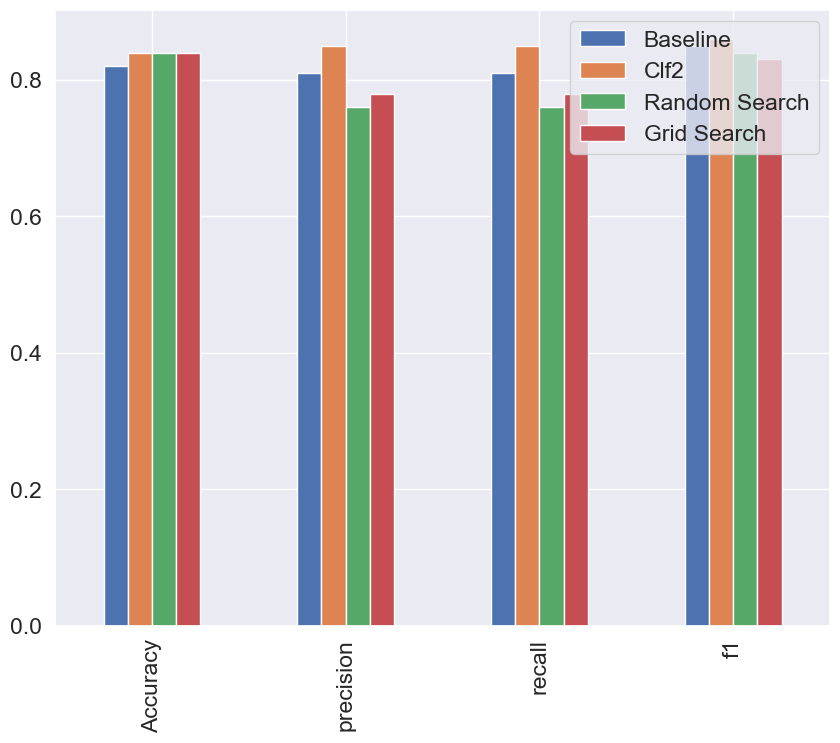

In [135]:
compare_metrics.plot.bar(figsize =(10,8));

#### Saving and Loading trained Machine learning Models

There are 2 ways of doin this, 
1. with Python's Pickle module
2. with the joblib module

In [137]:
# Using 'Pickle' module 

#save an exiting model to file 

import pickle
pickle.dump(gs_clf,open('gs_random_forest_model.pkl','wb'))


In [139]:
# Load a saved model 
loaded_pickel_model = pickle.load(open('gs_random_forest_model.pkl','rb'))

In [140]:
# making predictions with loaded model
pickle_loaded_preds = loaded_pickel_model.predict(X_test)

evalutate_preds(y_test,pickle_loaded_preds)

Acc:83.61%
Precision:0.78
recall:0.89
f1 score : 0.83


{'Accuracy': 0.84, 'precision': 0.78, 'recall': 0.78, 'f1': 0.83}

In [141]:
# saving and loading a trained model using joblind module 

from joblib import dump,load

# saving model to file 
dump(gs_clf,filename='gs_random_forest_jb.joblib')

['gs_random_forest_jb.joblib']

In [ ]:
#loading the saved joblib model

loaded_joblib_model = load(filename='gs_random_forest_jb.joblib')


In [143]:
#make and evaluate joblib predictions 

joblib_y_preds = loaded_joblib_model.predict(X_test)

evalutate_preds(y_test,joblib_y_preds)

Acc:83.61%
Precision:0.78
recall:0.89
f1 score : 0.83


{'Accuracy': 0.84, 'precision': 0.78, 'recall': 0.78, 'f1': 0.83}

### Model persistence

Sklearn advises to use joblid module in case if the model is large